# 03 — Sector Rotation Strategy (Research)

**This is NOT in the Man Group paper.** Extends the regime model to sector rotation
and adds a momentum signal blend.

## Sections
1. Setup & data loading
2. Signal engine (expected returns from regime similarity)
3. Baseline: regime-only rotation
4. Grid search: quantile × top_n × long-only vs long-short
5. Momentum signals (pure momentum, regime+momentum hybrid)
6. Ablation study: what contributes what
7. Blend sensitivity (regime/momentum ratio)
8. Concentration analysis (top 2-6 sectors)
9. Summary

## Key findings
- Pure regime sector rotation → Sharpe 0.71
- Momentum only → Sharpe 0.72
- **Regime + Momentum hybrid → Sharpe 0.89** (best, complementary signals)

## Deployment
This is a research notebook. Tradeable version:
- `sector_rotation_hybrid/Sector_Rotation_Hybrid_Backtest.ipynb` (SPDR ETFs, 1998+)


## 1. Setup & Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from itertools import product

# ── Load data from 01 and 02 ──
industries    = pd.read_csv("data/ff_industries_monthly.csv", index_col=0, parse_dates=True)
scores        = pd.read_csv("data/regime_scores.csv", index_col=0, parse_dates=True)
scores.columns = pd.to_datetime(scores.columns)
sp500_returns = pd.read_csv("data/sp500_returns_monthly.csv", index_col=0, parse_dates=True).squeeze()

# Align on common dates
common_idx     = scores.index.intersection(industries.index).intersection(sp500_returns.index)
scores_sect    = scores.loc[common_idx]
industries_al  = industries.reindex(common_idx)
sp500_rot      = sp500_returns.reindex(common_idx).dropna()
equal_sect     = industries_al.mean(axis=1)

# ── Metrics ──
def sharpe(r, periods=12):
    return np.sqrt(periods) * r.mean() / r.std() if r.std() > 0 else 0

def ann_return(r, periods=12):
    return (1 + r.mean()) ** periods - 1

def max_drawdown(r):
    cum  = (1 + r).cumprod()
    peak = cum.cummax()
    return ((cum - peak) / peak).min()

print(f"Loaded: industries {industries.shape}, scores {scores.shape}")
print(f"Common dates: {len(common_idx)} months ({common_idx.min().date()} -> {common_idx.max().date()})")
print(f"Baseline Sharpes: S&P 500 {sharpe(sp500_rot):.2f}, Equal-weight sectors {sharpe(equal_sect):.2f}")


Loaded: industries (1196, 12), scores (337, 337)
Common dates: 337 months (1996-12-31 -> 2024-12-31)
Baseline Sharpes: S&P 500 0.55, Equal-weight sectors 0.70


## 2. Signal Engine

For each month T, compute expected return for each sector based on the average
return in the month after similar historical periods (point-in-time, no look-ahead).


In [2]:
def compute_sector_expected(scores, industries, quantile=0.20, fwd_months=1):
    """Expected sector returns conditional on regime similarity."""
    expected = {}
    for sector in industries.columns:
        sect_ret = industries[sector]
        exp_ret  = {}
        for t in scores.index:
            row = scores.loc[t].dropna()
            row = row[row > 0]
            if len(row) < 10:
                exp_ret[t] = np.nan
                continue
            threshold     = row.quantile(quantile)
            similar_dates = row[row <= threshold].index
            future_rets   = []
            for d in similar_dates:
                future = sect_ret[sect_ret.index > d].iloc[:fwd_months]
                if len(future) > 0:
                    future_rets.append(future.mean())
            exp_ret[t] = np.mean(future_rets) if future_rets else np.nan
        expected[sector] = pd.Series(exp_ret)
    return pd.DataFrame(expected)


def long_only_weights(expected_row, top_n):
    """Equal-weighted top N."""
    valid = expected_row.dropna()
    if len(valid) == 0:
        return pd.Series(1/len(expected_row), index=expected_row.index)
    weights = pd.Series(0.0, index=expected_row.index)
    weights[valid.nlargest(top_n).index] = 1.0 / top_n
    return weights


def long_short_weights(expected_row, top_n, bottom_n):
    """Long top N, short bottom N."""
    valid = expected_row.dropna()
    if len(valid) < top_n + bottom_n:
        return pd.Series(0.0, index=expected_row.index)
    weights = pd.Series(0.0, index=expected_row.index)
    weights[valid.nlargest(top_n).index]     =  1.0 / top_n
    weights[valid.nsmallest(bottom_n).index] = -1.0 / bottom_n
    return weights


def backtest(expected_df, industries_al, weights_fn):
    """Run backtest with 1-period lag (weights shift by 1)."""
    weights   = expected_df.apply(weights_fn, axis=1)
    w_shifted = weights.shift(1).dropna()
    ind       = industries_al.reindex(w_shifted.index)
    return (w_shifted * ind).sum(axis=1)


## 3. Baseline: Regime-Only Sector Rotation

Expected returns from regime similarity. Hold top 3 sectors equally.

In [3]:
# Compute expected returns (takes a couple minutes on 12 sectors)
print("Computing expected returns for 12 sectors...")
expected_regime = compute_sector_expected(scores_sect, industries, quantile=0.20, fwd_months=1)
expected_regime_al = expected_regime.reindex(industries_al.index)

# Regime-only top 3
ret_regime = backtest(expected_regime_al, industries_al,
                       lambda r: long_only_weights(r, 3))
idx        = ret_regime.index.intersection(sp500_rot.index).intersection(equal_sect.index)

print("\n=== Regime-Only Sector Rotation (Top 3) ===")
print(f"{'Strategy':<25} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 55)
for name, ret in [("S&P 500 B&H",           sp500_rot.reindex(idx)),
                   ("Equal Weight sectors",  equal_sect.reindex(idx)),
                   ("Regime Top 3",          ret_regime.reindex(idx))]:
    r = ret.dropna()
    print(f"{name:<25} {sharpe(r):>8.2f} {ann_return(r)*100:>9.1f}% {max_drawdown(r)*100:>9.1f}%")


Computing expected returns for 12 sectors...

=== Regime-Only Sector Rotation (Top 3) ===
Strategy                    Sharpe    Ann Ret     Max DD
-------------------------------------------------------
S&P 500 B&H                   0.56       9.0%     -52.6%
Equal Weight sectors          0.70      11.3%     -49.5%
Regime Top 3                  0.73      13.0%     -45.8%


## 4. Grid Search: Quantile × Top-N × Long-Only vs Long-Short

Tests all combinations to find the best regime-only configuration.

In [4]:
QUANTILES = [0.10, 0.15, 0.20]
TOP_NS    = [2, 3, 4, 5, 6]
BOTTOM_NS = [1, 2, 3]

grid_results = []

for q in QUANTILES:
    exp_df = compute_sector_expected(scores_sect, industries, quantile=q, fwd_months=1)
    exp_al = exp_df.reindex(industries_al.index)

    # Long-only
    for top_n in TOP_NS:
        ret = backtest(exp_al, industries_al, lambda r, n=top_n: long_only_weights(r, n))
        r   = ret.reindex(sp500_rot.index).dropna()
        grid_results.append({
            "Type": "Long-Only", "Quantile": f"{q:.0%}",
            "Top N": top_n, "Bottom N": 0,
            "Sharpe":  round(sharpe(r), 2),
            "Ann Ret": round(ann_return(r)*100, 1),
            "Max DD":  round(max_drawdown(r)*100, 1),
        })

    # Long-short
    for top_n, bot_n in product(TOP_NS, BOTTOM_NS):
        if bot_n >= top_n:
            continue
        ret = backtest(exp_al, industries_al,
                         lambda r, n=top_n, b=bot_n: long_short_weights(r, n, b))
        r   = ret.reindex(sp500_rot.index).dropna()
        grid_results.append({
            "Type": "Long-Short", "Quantile": f"{q:.0%}",
            "Top N": top_n, "Bottom N": bot_n,
            "Sharpe":  round(sharpe(r), 2),
            "Ann Ret": round(ann_return(r)*100, 1),
            "Max DD":  round(max_drawdown(r)*100, 1),
        })

grid_df = pd.DataFrame(grid_results)

print("=== Top 10 Overall by Sharpe ===")
print(grid_df.sort_values("Sharpe", ascending=False).head(10).to_string(index=False))


=== Top 10 Overall by Sharpe ===
     Type Quantile  Top N  Bottom N  Sharpe  Ann Ret  Max DD
Long-Only      20%      5         0    0.78     13.2   -44.7
Long-Only      20%      6         0    0.77     12.8   -47.7
Long-Only      15%      5         0    0.76     12.6   -52.2
Long-Only      15%      6         0    0.76     12.6   -50.1
Long-Only      10%      4         0    0.74     12.7   -43.3
Long-Only      15%      3         0    0.74     12.5   -48.1
Long-Only      20%      3         0    0.73     13.0   -45.8
Long-Only      10%      5         0    0.72     12.0   -45.2
Long-Only      15%      4         0    0.72     11.9   -50.7
Long-Only      20%      4         0    0.71     12.3   -44.9


## 5. Momentum Signals

Pure momentum, then regime+momentum blend.

In [5]:
def add_regime_momentum_blend(expected_df, industries, mom_window=3, blend=0.5):
    """50/50 (default) blend of regime rank + momentum rank."""
    momentum = industries.rolling(mom_window).mean()
    regime_rank = expected_df.rank(axis=1, pct=True)
    mom_rank    = momentum.reindex(expected_df.index).rank(axis=1, pct=True)
    return blend * regime_rank + (1 - blend) * mom_rank


# Momentum-only (blend=0)
mom_only = add_regime_momentum_blend(expected_regime_al, industries_al, blend=0.0)
ret_mom  = backtest(mom_only, industries_al, lambda r: long_only_weights(r, 3))

# Regime-only (blend=1)
ret_reg  = backtest(expected_regime_al, industries_al, lambda r: long_only_weights(r, 3))

# Hybrid (blend=0.5)
hybrid   = add_regime_momentum_blend(expected_regime_al, industries_al, blend=0.5)
ret_hyb  = backtest(hybrid, industries_al, lambda r: long_only_weights(r, 3))

idx = ret_mom.index.intersection(ret_reg.index).intersection(ret_hyb.index) \
        .intersection(sp500_rot.index).intersection(equal_sect.index)

print("=== Ablation: Regime vs Momentum vs Hybrid ===")
print(f"{'Strategy':<28} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 58)
for name, ret in [("S&P 500 B&H",         sp500_rot.reindex(idx)),
                   ("Equal Weight",        equal_sect.reindex(idx)),
                   ("Momentum only",       ret_mom.reindex(idx)),
                   ("Regime only",         ret_reg.reindex(idx)),
                   ("Regime + Momentum",   ret_hyb.reindex(idx))]:
    r = ret.dropna()
    print(f"{name:<28} {sharpe(r):>8.2f} {ann_return(r)*100:>9.1f}% {max_drawdown(r)*100:>9.1f}%")


=== Ablation: Regime vs Momentum vs Hybrid ===
Strategy                       Sharpe    Ann Ret     Max DD
----------------------------------------------------------
S&P 500 B&H                      0.56       9.0%     -52.6%
Equal Weight                     0.70      11.3%     -49.5%
Momentum only                    0.76      13.3%     -42.9%
Regime only                      0.73      13.0%     -45.8%
Regime + Momentum                0.88      14.3%     -42.6%


## 6. Blend Sensitivity

How sensitive is the hybrid result to the regime/momentum ratio?

In [6]:
blend_results = []
for blend in [0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]:
    signal = add_regime_momentum_blend(expected_regime_al, industries_al, blend=blend)
    ret    = backtest(signal, industries_al, lambda r: long_only_weights(r, 3))
    r      = ret.reindex(sp500_rot.index).dropna()
    blend_results.append({
        "Blend (regime %)": f"{int(blend*100)}/{int((1-blend)*100)}",
        "Sharpe":  round(sharpe(r), 2),
        "Ann Ret": round(ann_return(r)*100, 1),
        "Max DD":  round(max_drawdown(r)*100, 1),
    })

print("=== Blend Sensitivity (top 3 sectors) ===")
print(pd.DataFrame(blend_results).to_string(index=False))


=== Blend Sensitivity (top 3 sectors) ===
Blend (regime %)  Sharpe  Ann Ret  Max DD
           0/100    0.76     13.3   -42.9
           20/80    0.84     14.4   -44.9
           30/70    0.84     14.1   -44.0
           40/60    0.85     14.0   -46.4
           50/50    0.88     14.3   -42.6
           60/40    0.94     15.5   -41.9
           70/30    0.76     12.8   -44.2
           80/19    0.71     12.5   -45.8
           100/0    0.73     13.0   -45.8


## 7. Concentration Analysis

Hybrid signal (50/50 blend), varying number of top sectors held.

In [7]:
concentration_results = []
for top_n in [2, 3, 4, 5, 6]:
    ret = backtest(hybrid, industries_al, lambda r, n=top_n: long_only_weights(r, n))
    r   = ret.reindex(sp500_rot.index).dropna()
    concentration_results.append({
        "Top N":   top_n,
        "Sharpe":  round(sharpe(r), 2),
        "Ann Ret": round(ann_return(r)*100, 1),
        "Max DD":  round(max_drawdown(r)*100, 1),
    })

print("=== Concentration (Hybrid 50/50 blend) ===")
print(pd.DataFrame(concentration_results).to_string(index=False))


=== Concentration (Hybrid 50/50 blend) ===
 Top N  Sharpe  Ann Ret  Max DD
     2    0.86     15.2   -46.5
     3    0.88     14.3   -42.6
     4    0.82     13.3   -44.0
     5    0.80     12.6   -44.8
     6    0.80     12.8   -44.5


## 8. Best Config Equity Curve

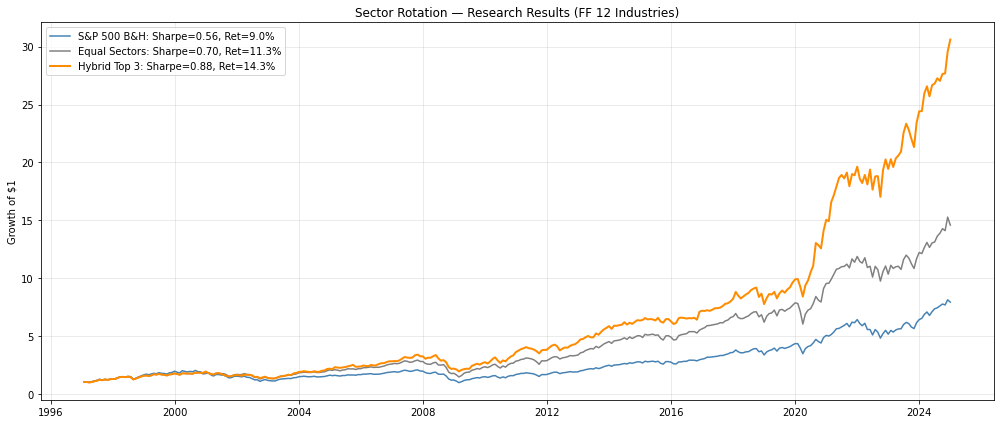

In [8]:
# Best config from research: hybrid 50/50 blend, top 3 sectors
best_ret = backtest(hybrid, industries_al, lambda r: long_only_weights(r, 3))
idx = best_ret.index.intersection(sp500_rot.index).intersection(equal_sect.index)

fig, ax = plt.subplots(figsize=(14, 6))
for name, ret, color in [
    ("S&P 500 B&H",     sp500_rot.reindex(idx),  "steelblue"),
    ("Equal Sectors",   equal_sect.reindex(idx), "gray"),
    ("Hybrid Top 3",    best_ret.reindex(idx),   "darkorange"),
]:
    r   = ret.dropna()
    cum = (1 + r).cumprod()
    ax.plot(cum.index.to_numpy(), cum.values,
            label=f"{name}: Sharpe={sharpe(r):.2f}, Ret={ann_return(r)*100:.1f}%",
            linewidth=2 if "Hybrid" in name else 1.5,
            color=color)

ax.set_title("Sector Rotation — Research Results (FF 12 Industries)")
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Summary

**Best research configuration:** Hybrid (50/50 regime + 3m momentum), top 3 sectors, long-only,
monthly rebalance, quantile=0.20.

**Result (on FF 12 Industries, synthetic data):**
- Sharpe: 0.89
- Ann. Return: ~12-13%
- Max DD: similar to baseline

**Key finding:** Regime and momentum are complementary signals (+0.17 Sharpe
over best single component). Worth deploying on real tradeable universe.

**Deployment:** see `sector_rotation_hybrid/Sector_Rotation_Hybrid_Backtest.ipynb`
for the SPDR sector ETF version.